## Traffic Assignments for system ownership outage scenarios

In this notebook geographic cluster outages are simulated by removing cable systems passinng through them them from the network and the traffic assignment is run iteratively for each cluster being removed and the results are saved


In [12]:
import geopandas as gpd
from shapely.geometry import Point, MultiPoint, LineString, MultiLineString, MultiPolygon, Polygon, box
from shapely.ops import split
from geopy.distance import geodesic
import pandas as pd
import os
import re
import networkx as nx
from shapely.ops import unary_union # For distance calc
from pyproj import Geod, CRS, Transformer # For distance calc projection
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.sample import sample_gen
import numpy as np
import math
import logging
from contextlib import contextmanager
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import time
from geopy.geocoders import MapBox
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
from tqdm.notebook import tqdm
from dotenv import load_dotenv
import pickle
import requests # Not used currently
import json # Not used currently
#Import required packages and modules
#import qgis
import PyQt5
from aequilibrae import Graph, AequilibraeMatrix, TrafficClass, TrafficAssignment
from aequilibrae.matrix import AequilibraeMatrix
from aequilibrae.paths import Graph
from aequilibrae.paths import TrafficAssignment
from aequilibrae.paths.traffic_class import TrafficClass
#from qgis.core import QgsVectorLayer, QgsField, QgsFeature, QgsPointXY, QgsProject, QgsGeometry, QgsVectorFileWriter
from PyQt5.QtCore import QVariant 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import ast

Here, various functions such as ```unwrap_linestring``` and ```create_box``` are written to create boxes to show the different geographic clusters and record the number of cable systems passing through each cluster.

C:\Users\Dean\AppData\Local\Temp\ipykernel_29480\1205240538.py:30: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'Polygon':
C:\Users\Dean\AppData\Local\Temp\ipykernel_29480\1205240538.py:34: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  elif geom.type == 'MultiPolygon':
Skipping field path_nodes: unsupported OGR type: 5
C:\Users\Dean\AppData\Local\Temp\ipykernel_29480\1205240538.py:20: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'LineString':
Skipping field path_nodes: unsupported OGR type: 5
C:\Users\Dean\AppData\Local\Temp\ipykernel_29480\1205240538.py:20: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. 

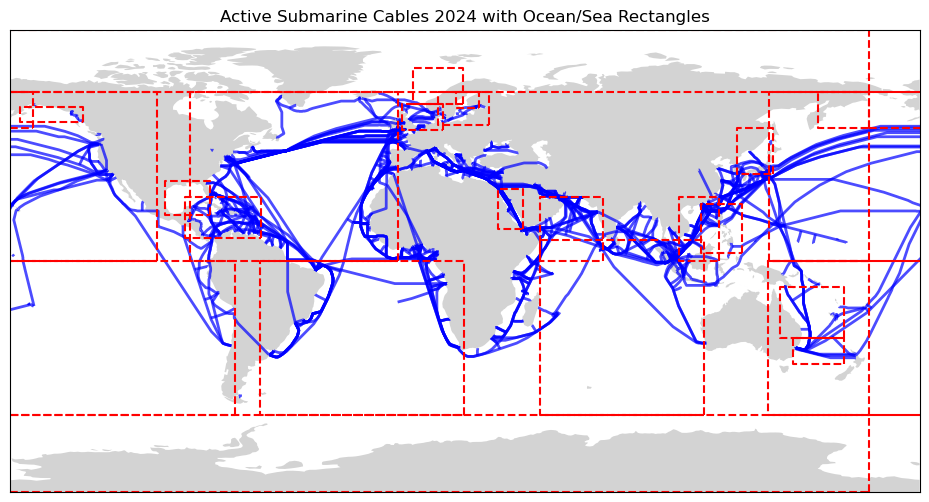

In [13]:
def unwrap_linestring(line):
    coords = list(line.coords)
    if not coords:
        return line
    new_coords = [coords[0]]
    offset = 0
    prev_lon = coords[0][0]
    for lon, lat in coords[1:]:
        dlon = lon + offset - prev_lon
        if dlon < -180:
            offset += 360
        elif dlon > 180:
            offset -= 360
        new_lon = lon + offset
        new_coords.append((new_lon, lat))
        prev_lon = new_lon
    return LineString(new_coords)

def unwrap_geometry(geom):
    if geom.type == 'LineString':
        return unwrap_linestring(geom)
    elif geom.type == 'MultiLineString':
        return MultiLineString([unwrap_linestring(line) for line in geom.geoms])
    else:
        return geom

def shift_longitude(geom, shift):
    def shift_coords(coords):
        return [(lon + shift, lat) for lon, lat in coords]
    if geom.type == 'Polygon':
        exterior = shift_coords(geom.exterior.coords)
        interiors = [shift_coords(interior.coords) for interior in geom.interiors]
        return Polygon(exterior, interiors)
    elif geom.type == 'MultiPolygon':
        return MultiPolygon([shift_longitude(part, shift) for part in geom.geoms])
    elif geom.type == 'LineString':
        return LineString(shift_coords(geom.coords))
    elif geom.type == 'MultiLineString':
        return MultiLineString([shift_longitude(line, shift) for line in geom.geoms])
    else:
        return geom

# Load world map from public URL (Natural Earth countries)
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/physical/ne_110m_land.zip")

# Create bounding box for longitude between -180 and -160
bbox = box(-180, -90, -160, 90)

# Clip world map geometries to the bounding box
world_clipped = world.copy()
world_clipped['geometry'] = world_clipped.geometry.intersection(bbox)
world_clipped = world_clipped[~world_clipped.is_empty]

# Shift world map by +360 degrees longitude
world_shifted = world_clipped.copy()
world_shifted['geometry'] = world_shifted['geometry'].apply(lambda geom: shift_longitude(geom, 360))

# Folder containing GeoJSON files
folder_path = 'C:/Users/Dean/Downloads/IfW/New folder (5)'

# List all GeoJSON files in the folder
geojson_files = [f for f in os.listdir(folder_path) if f.endswith('.geojson')]

# Prepare the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each GeoJSON file
for file in geojson_files:
    file_path = os.path.join(folder_path, file)
    gdf = gpd.read_file(file_path)
    gdf['geometry'] = gdf['geometry'].apply(unwrap_geometry)
    gdf.plot(ax=ax, linewidth=2, edgecolor='blue', alpha=0.7, label=file)

world.plot(ax=ax, color='lightgray', edgecolor='none', linewidth=0.5, zorder=0)
world_shifted.plot(ax=ax, color='lightgray', edgecolor='none', linewidth=0.5, zorder=0)

# Define the ocean and sea rectangles as longitude, latitude pairs (min_lon, min_lat, max_lon, max_lat)
ocean_sea_rectangles = {
    "North Pacific": (140.52, 0.0, -100.99, 66.0),
    "South Pacific": (140.11, -60.0, -70.27, 0.0),
    "North Atlantic": (-88.05, 0.0, -6.0, 66.0),
    "South Atlantic": (-60.5, -60.0, 20.01, 0.0),
    "Indian Ocean": (50.0, -60.0, 115.0, 8.0),
    "Arctic Ocean": (-180.0, 66.0, 180.0, 90.0),
    "Southern Ocean": (-180.0, -90.0, 180.0, -60.0),
    "Bering Sea": (160.0, 52.0, -150.0, 66.0),
    "Gulf of Alaska": (-155.0, 54.0, -130.0, 60.0),
    "Sea of Japan": (128.0, 34.0, 142.0, 52.0),
    "South China Sea": (105.0, 0.0, 121.0, 25.0),
    "Coral Sea": (145.0, -30.0, 170.0, -10.0),
    "Tasman Sea": (150.0, -40.0, 170.0, -30.0),
    "Red Sea": (33.64, 12.46, 43.51, 28.14),
    "Baltic Sea": (10.0, 53.0, 30.0, 66.0),
    "Arabian Sea": (50.0, 0.0, 75.0, 25.0),
    "Philippine Sea": (113.68, 3.11, 129.94, 22.25),
    "Gulf of Mexico": (-98.0, 18.0, -80.0, 31.0),
    "Caribbean Sea": (-90.0, 9.0, -60.0, 25.0),
    "North Sea": (-4.45, 51.0, 12.01, 61.02),
    "Norwegian Sea": (0.0, 61.0, 20.0, 75.0),
    "Gulf of Bothnia": (17.0, 59.8, 26.0, 65.9)
}

def create_box(min_lon, min_lat, max_lon, max_lat):
    # If max_lon < min_lon, it means crossing the dateline
    if max_lon < min_lon:
        # Create two boxes: from min_lon to 180 and from -180 to max_lon
        box1 = box(min_lon, min_lat, 180, max_lat)
        box2 = box(-180, min_lat, max_lon, max_lat)
        return [box1, box2]
    else:
        return [box(min_lon, min_lat, max_lon, max_lat)]

# Create a dictionary of polygons (or list of polygons) for each ocean/sea
polygon_rectangles = {}
for name, (min_lon, min_lat, max_lon, max_lat) in ocean_sea_rectangles.items():
    polygon_rectangles[name] = create_box(min_lon, min_lat, max_lon, max_lat)

# Plot the ocean and sea rectangles
for name, polygons in polygon_rectangles.items():
    for i, poly in enumerate(polygons):
        x, y = poly.exterior.xy
        ax.plot(x, y, color='red', linewidth=1.5, linestyle='--', label='Ocean/Sea Rectangle' if name == 'North Pacific' and i == 0 else "")
        # Optionally add text label at centroid
        cx, cy = poly.centroid.xy
        #ax.text(cx[-1], cy[0], name, fontsize=10, color='red', alpha=0.7)

# Plot horizontal line at 66 latitude between 180 and 200 longitude
ax.plot([180, 200], [66, 66], color='red', linewidth=1.5, linestyle='-')

# Plot horizontal line at -60 latitude between 180 and 200 longitude
ax.plot([180, 200], [-60, -60], color='red', linewidth=1.5, linestyle='-')

# Plot horizontal line at 66 latitude between 180 and 200 longitude
ax.plot([180, 200], [52, 52], color='red', linewidth=1.5, linestyle='--')

# Plot horizontal line at -60 latitude between 180 and 200 longitude
ax.plot([140.11, 200], [0, 0], color='red', linewidth=1.5, linestyle='-')

ax.set_xlim(-159, 200)
ax.set_ylim(-90, 90)
ax.set_title('Active Submarine Cables 2024 with Ocean/Sea Rectangles')
ax.set_xticks([])
ax.set_yticks([])

# Avoid duplicate labels in legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
#ax.legend(by_label.values(), by_label.keys())

plt.show()


In [14]:
# Create rectangle polygons (handle dateline crossing)
rectangles = {}
for name, (min_lon, min_lat, max_lon, max_lat) in ocean_sea_rectangles.items():
    if max_lon < min_lon:
        box1 = box(min_lon, min_lat, 180, max_lat)
        box2 = box(-180, min_lat, max_lon, max_lat)
        rectangles[name] = [box1, box2]
    else:
        rectangles[name] = [box(min_lon, min_lat, max_lon, max_lat)]

# Folder path for GeoJSON files
folder_path = 'C:/Users/Dean/Downloads/IfW/New folder (5)'

# List all GeoJSON files
geojson_files = [f for f in os.listdir(folder_path) if f.endswith('.geojson')]

# Extract System_ID from filenames
pattern = re.compile(r'paths_(.*?)_')
system_geometries = {}
for file in geojson_files:
    match = pattern.search(file)
    if match:
        system_id = match.group(1)
        file_path = os.path.join(folder_path, file)
        gdf = gpd.read_file(file_path)
        gdf['geometry'] = gdf['geometry'].apply(unwrap_geometry)
        system_geometries[system_id] = gdf

# Check intersections and record results
results = []
for ocean_sea, polys in rectangles.items():
    for system_id, gdf in system_geometries.items():
        for poly in polys:
            if gdf.intersects(poly).any():
                results.append({'Ocean/Sea': ocean_sea, 'System_ID': system_id})

# Create DataFrame
df_results = pd.DataFrame(results)

# Group by Ocean/Sea and aggregate System_IDs as list
summary_df = df_results.groupby('Ocean/Sea')['System_ID'].apply(list).reset_index()

# Add "number of systems removed" column
summary_df['number of systems removed'] = summary_df['System_ID'].apply(lambda id_list: len(set(id_list)))

# Display the result
summary_df

Skipping field path_nodes: unsupported OGR type: 5
C:\Users\Dean\AppData\Local\Temp\ipykernel_29480\1205240538.py:20: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'LineString':
Skipping field path_nodes: unsupported OGR type: 5
C:\Users\Dean\AppData\Local\Temp\ipykernel_29480\1205240538.py:20: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'LineString':
Skipping field path_nodes: unsupported OGR type: 5
C:\Users\Dean\AppData\Local\Temp\ipykernel_29480\1205240538.py:20: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'LineString':
Skipping field path_nodes: unsupported OGR type: 5
C:\Users\Dean\AppData\Local\Temp\ipykernel_29480\1205240538.py:2

,Ocean/Sea,System_ID,number of systems removed
0,Arabian Sea,"[2002.7, 2004.5, 2005.3, 2006.10, 2006.17, 200...",26
1,Baltic Sea,"[2000.10, 2000.11, 2000.12, 2000.28, 2000.29, ...",16
2,Bering Sea,[2008.6],1
3,Caribbean Sea,"[2000.13, 2000.15, 2000.16, 2000.18, 2000.27, ...",30
4,Coral Sea,"[2000.33, 2001.6, 2006.6, 2008.4, 2009.4, 2014...",10
5,Gulf of Alaska,"[2008.15, 2020.11]",2
6,Gulf of Bothnia,"[2000.11, 2000.6, 2006.8, 2016.7, 2019.2]",5
7,Gulf of Mexico,"[2000.13, 2000.15, 2000.16, 2000.3, 2001.11, 2...",12
8,Indian Ocean,"[2001.16, 2002.1, 2002.7, 2002.8, 2004.4, 2005...",54
9,North Atlantic,"[2000.13, 2000.15, 2000.16, 2000.18, 2000.1, 2...",78


In [15]:
summary_df

,Ocean/Sea,System_ID,number of systems removed
0,Arabian Sea,"[2002.7, 2004.5, 2005.3, 2006.10, 2006.17, 200...",26
1,Baltic Sea,"[2000.10, 2000.11, 2000.12, 2000.28, 2000.29, ...",16
2,Bering Sea,[2008.6],1
3,Caribbean Sea,"[2000.13, 2000.15, 2000.16, 2000.18, 2000.27, ...",30
4,Coral Sea,"[2000.33, 2001.6, 2006.6, 2008.4, 2009.4, 2014...",10
5,Gulf of Alaska,"[2008.15, 2020.11]",2
6,Gulf of Bothnia,"[2000.11, 2000.6, 2006.8, 2016.7, 2019.2]",5
7,Gulf of Mexico,"[2000.13, 2000.15, 2000.16, 2000.3, 2001.11, 2...",12
8,Indian Ocean,"[2001.16, 2002.1, 2002.7, 2002.8, 2004.4, 2005...",54
9,North Atlantic,"[2000.13, 2000.15, 2000.16, 2000.18, 2000.1, 2...",78


In the code, the ```split_antimeridian_line```, ```plot_traffic```, and ```process_scenario``` functions are reused from the code which runs the baseline scenario found in the notebook titled "TA Baseline & Plotting" within the repository.

In [4]:
# 1. Load data
od_data = pd.read_csv("OD_filtered.csv")

def split_antimeridian_line(start, end):
    lon1, lat1 = start
    lon2, lat2 = end
    
    # Check if line crosses antimeridian
    if abs(lon1 - lon2) <= 180:
        # No crossing, return as is
        return [((lon1, lat1), (lon2, lat2))]
    
    # Crossing detected: split into two segments
    crossing_lon = 180 if lon1 > 0 else -180
    
    # Linear interpolation to find crossing latitude
    if lon2 != lon1:
        ratio = (crossing_lon - lon1) / (lon2 - lon1)
    else:
        ratio = 0.5  # Arbitrary if same longitude
    
    crossing_lat = lat1 + ratio * (lat2 - lat1)
    
    # First segment: start to crossing point
    segment1_end = (crossing_lon, crossing_lat)
    # Second segment: crossing point (wrapped) to end
    if lon1 > lon2:
        segment2_start = (crossing_lon - 360, crossing_lat)
    else:
        segment2_start = (crossing_lon + 360, crossing_lat)
    
    return [((lon1, lat1), segment1_end), (segment2_start, (lon2, lat2))]

def plot_traffic(merged_data, nodes, traffic_col='traffic_all', title=None):
    fig, ax = plt.subplots(figsize=(15, 10))
    max_flow = merged_data[traffic_col].max()
    norm = mcolors.Normalize(vmin=0, vmax=max_flow)
    cmap = plt.cm.viridis

    for _, link in merged_data.iterrows():
        start_node = nodes[nodes['Hop_ID'] == link['start_point_idx']]
        end_node = nodes[nodes['Hop_ID'] == link['end_point_idx']]
        
        if not start_node.empty and not end_node.empty:
            # Capital link detection and conditional plotting
            is_capital_link = (link['Start Node'].startswith('capital_') 
                              and link['End Node'].startswith('capital_'))
            
            if is_capital_link:
                if link[traffic_col] <= 0:
                    continue  # Skip non-active capital links
                line_color = 'red'
            else:
                line_color = cmap(norm(link[traffic_col]))

            width = 2.5 + 14 * (link[traffic_col] / max_flow if max_flow > 0 else 0)

            start_coords = (start_node['Longitude'].values[0], start_node['Latitude'].values[0])
            end_coords = (end_node['Longitude'].values[0], end_node['Latitude'].values[0])

            # Split line if crossing antimeridian
            segments = split_antimeridian_line(start_coords, end_coords)
            for seg_start, seg_end in segments:
                ax.plot(
                    [seg_start[0], seg_end[0]],
                    [seg_start[1], seg_end[1]],
                    color=line_color,
                    linewidth=width,
                    alpha=0.7,
                    zorder=1
                )

    # Plot nodes (same as your original code)
    landing_points = nodes[nodes['Node ID'].str.startswith('pt')]
    ax.scatter(
        landing_points['Longitude'], landing_points['Latitude'],
        color='blue', s=60, marker='o', edgecolor='black', linewidth=1,
        label='Landing Points', zorder=3
    )
    grid_points = nodes[nodes['Node ID'].str.startswith('grid')]
    ax.scatter(
        grid_points['Longitude'], grid_points['Latitude'],
        color='green', s=40, marker='s', edgecolor='black', linewidth=1,
        label='Junction Points', zorder=2
    )
    capitals = nodes[nodes['Node ID'].str.startswith('capital')]
    ax.scatter(
        capitals['Longitude'], capitals['Latitude'],
        color='red', s=100, marker='^', edgecolor='black', linewidth=1,
        label='Capital Cities', zorder=4
    )
    for _, capital in capitals.iterrows():
        city_name = capital['Name'].split(',')[0]
        ax.annotate(
            city_name,
            (capital['Longitude'], capital['Latitude']),
            xytext=(5, 5), textcoords='offset points',
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Traffic Flow Volume', fontsize=12)
    ax.set_title(title or f'Traffic Flows: {traffic_col}', fontsize=16)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='lower right')

    # Add text showing top flows
    top_flows = merged_data.sort_values(traffic_col, ascending=False).head(3)
    flow_text = "Top Flows:\n"
    for i, (_, flow) in enumerate(top_flows.iterrows(), 1):
        if 'Start Name' in flow and 'End Name' in flow:
            start = flow['Start Name'].split(',')[0] if ',' in flow['Start Name'] else flow['Start Name']
            end = flow['End Name'].split(',')[0] if ',' in flow['End Name'] else flow['End Name']
            flow_text += f"{i}. {start} → {end}: {flow[traffic_col]:.1f}\n"
    ax.text(0.02, 0.02, flow_text, transform=ax.transAxes, 
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'),
            fontsize=9)

    plt.tight_layout()
    plt.show()

def print_active_links(merged_data, traffic_col):
    active_links = merged_data[merged_data[traffic_col] > 0]['link_id']
    print(f"Active links for {traffic_col} (traffic > 0):")
    for link_id in active_links:
        print(link_id)
    return active_links.tolist()

In [5]:
def process_scenario(nodes_df, links_df, od_data):
    # 1. Set relevant_countries to the unique, non-null values in the 'Country' column
    relevant_countries = set(nodes_df['Country'].dropna().unique())

    # 2. Read capitals.csv and filter for relevant countries
    capitals_raw = pd.read_csv("capitals.csv")
    capitals_filtered = capitals_raw[capitals_raw['Country'].isin(relevant_countries)]

    # 3. Create dictionary mapping countries to their capitals and coordinates
    country_capitals = {
        row['Country']: (row['Capital'], row['Longitude'], row['Latitude'])
        for _, row in capitals_filtered.iterrows()
    }

    # 4. Create capital nodes
    max_hop = nodes_df['Hop_ID'].max()
    capital_nodes = []
    for idx, (country, (capital, lon, lat)) in enumerate(country_capitals.items(), 1):
        capital_nodes.append({
            'Node ID': f"capital_{country.replace(' ', '_')}",
            'Name': f"{capital}, {country}",
            'Longitude': lon,
            'Latitude': lat,
            'Hop_ID': max_hop + idx
        })
    capitals_df = pd.DataFrame(capital_nodes)
    nodes_df = pd.concat([nodes_df, capitals_df], ignore_index=True)

    # 5. Connect landing points to capitals
    capital_links = []
    for _, lp in nodes_df[nodes_df['Node ID'].str.startswith('pt')].iterrows():
        country = lp['Country']  # Use the country column directly
        if country in country_capitals:
            capital = capitals_df[capitals_df['Name'].str.endswith(country)].iloc[0]
            capital_links.append({
                'Edge ID': f"{lp['Node ID']}-{capital['Node ID']}",
                'Start Node': lp['Node ID'],
                'Start Name': lp['Name'],
                'Start Coordinates': f"({lp['Longitude']}, {lp['Latitude']})",
                'End Node': capital['Node ID'],
                'End Name': capital['Name'],
                'End Coordinates': f"({capital['Longitude']}, {capital['Latitude']})",
                'distance': 50,
                'start_point_idx': lp['Hop_ID'],
                'end_point_idx': capital['Hop_ID']
            })
    if capital_links:
        capital_links_df = pd.DataFrame(capital_links)
        links_df = pd.concat([links_df, capital_links_df], ignore_index=True)

    # Fill empty distance_km with distance
    links_df.loc[links_df['distance_km'].isna(), 'distance_km'] = links_df['distance']

    # Drop the distance column
    links_df = links_df.drop(columns=['distance'], errors='ignore')

    # Create capital-to-capital links
    capital_to_capital_links = []
    for i, row_i in capitals_df.iterrows():
        for j, row_j in capitals_df.iterrows():
            if i != j:  # Avoid self-connections
                capital_to_capital_links.append({
                    'Edge ID': f"{row_i['Node ID']}-{row_j['Node ID']}",
                    'Start Node': row_i['Node ID'],
                    'Start Name': row_i['Name'],
                    'Start Coordinates': f"({row_i['Longitude']}, {row_i['Latitude']})",
                    'End Node': row_j['Node ID'],
                    'End Name': row_j['Name'],
                    'End Coordinates': f"({row_j['Longitude']}, {row_j['Latitude']})",
                    'distance_km': 1e6,  # Fixed distance between capitals
                    'start_point_idx': row_i['Hop_ID'],
                    'end_point_idx': row_j['Hop_ID']
                })
    if capital_to_capital_links:
        capital_to_capital_links_df = pd.DataFrame(capital_to_capital_links)
        links_df = pd.concat([links_df, capital_to_capital_links_df], ignore_index=True)

    # 6. Create network DataFrame
    network = pd.DataFrame({
        'link_id': range(1, len(links_df)+1),
        'a_node': links_df['start_point_idx'].astype(int),
        'b_node': links_df['end_point_idx'].astype(int),
        'direction': 0,
        'capacity': 13570,
        'free_flow_time': links_df['distance_km'] / (299792 * 0.75),  # using 75% the speed of light in km/h
    })

    # NOTE: The following code assumes you have defined Graph, TrafficAssignment, AequilibraeMatrix, TrafficClass classes
    # If you do not, you will need to import them or define them.
    g = Graph()
    g.network = network
    g.status = 'OK'
    centroids = capitals_df['Hop_ID'].unique().astype(int)
    g.prepare_graph(centroids)
    g.set_graph("free_flow_time")

    # 8. Create mapping from country name to capital Hop_ID
    country_to_hop = {country: capitals_df[capitals_df['Name'].str.contains(country)]['Hop_ID'].values[0] 
                      for country in country_capitals.keys()}

    # 9. Automatically detect all countries present in OD data and in the mapping
    all_countries = set(od_data['Country1'].str.strip()) | set(od_data['Country2'].str.strip())
    countries_of_interest = sorted([c for c in all_countries if c in country_to_hop])

    # 10. Prepare OD matrices for each country of interest and for 'others'
    od_matrices = {country: np.zeros((len(centroids), len(centroids)), dtype=np.float64) for country in countries_of_interest}
    od_matrices['others'] = np.zeros((len(centroids), len(centroids)), dtype=np.float64)

    for _, row in od_data.iterrows():
        orig_country = row['Country1'].strip()
        dest_country = row['Country2'].strip()
        flow = row['Flow']
        try:
            orig_hop = country_to_hop[orig_country]
            dest_hop = country_to_hop[dest_country]
            orig_idx = np.where(centroids == orig_hop)[0][0]
            dest_idx = np.where(centroids == dest_hop)[0][0]
            if orig_country in countries_of_interest:
                od_matrices[orig_country][orig_idx, dest_idx] = flow
            else:
                od_matrices['others'][orig_idx, dest_idx] = flow
        except KeyError:
            pass

    # 11. Create Aequilibrae matrices and add as classes
    matrices = {}
    assig = TrafficAssignment()
    for country, matrix_data in od_matrices.items():
        mat = AequilibraeMatrix()
        mat.create_empty(zones=len(centroids), matrix_names=['matrix'], memory_only=True)
        mat.index[:] = centroids
        mat.matrix['matrix'][:, :] = matrix_data
        mat.computational_view(['matrix'])
        matrices[country] = mat
        assig.add_class(TrafficClass(country, g, mat))

    # 12. Assignment settings
    assig.set_vdf('BPR')
    assig.set_vdf_parameters({'alpha': 0.15, 'beta': 1.0})
    assig.set_capacity_field('capacity')
    assig.set_time_field('free_flow_time')
    assig.set_algorithm('bfw')
    assig.max_iter = 180
    assig.rgap_target = 1e-4

    assig.execute()
    results = assig.results()

    # 13. Rename columns for clarity and add total traffic column
    for i, country in enumerate(matrices.keys()):
        col_idx = 2 + 3*i  # traffic column index pattern
        if col_idx < len(results.columns):
            results.columns.values[col_idx] = f'traffic_{country.replace(" ", "_")}'
    traffic_cols = [col for col in results.columns if col.startswith('traffic_')]
    results['traffic_all'] = results[traffic_cols].sum(axis=1)

    # Rename by position
    traffic = results
    traffic = traffic.reset_index()
    if 'link_id1' not in traffic.columns:
        traffic = traffic.reset_index().rename(columns={'index': 'link_id1'})

    # Link the traffic data with the network links
    merged_data = pd.merge(
        links_df,
        traffic,
        left_index=True,
        right_on='link_id1',
        how='left'
    )

    # 1. Get list of origin countries from OD data (excluding 'others')
    countries = [c for c in od_matrices.keys() if c != 'others']

    # 2. Map capital node IDs to country names
    capital_to_country = {
        row['Node ID']: row['Name'].split(', ')[-1]
        for _, row in capitals_df.iterrows()
    }

    # 3. Identify all capital-to-capital links in the network
    capital_links_mask = (links_df['Start Node'].str.startswith('capital_')) & \
                         (links_df['End Node'].str.startswith('capital_'))
    capital_link_ids = links_df[capital_links_mask].index

    # 4. Create country links dataframe
    country_links_data = []
    for country in countries:
        traffic_col = f'traffic_{country.replace(" ", "_")}'
        active_links = results[results[traffic_col] > 0].index

        # Existing metrics
        system_ids = links_df.loc[active_links, 'system_ID'].unique()
        avg_voc = results.loc[active_links, 'VOC_max'].mean() if 'VOC_max' in results.columns else None
        avg_delay = results.loc[active_links, 'Delay_factor_Max'].mean() if 'Delay_factor_Max' in results.columns else None
        avg_traffic = results.loc[active_links, 'traffic_all'].mean() if 'traffic_all' in results.columns else None

        # Capital link detection
        capital_mask = (links_df.loc[active_links, 'Start Node'].str.startswith('capital_')) & \
                       (links_df.loc[active_links, 'End Node'].str.startswith('capital_'))
        uses_capital = capital_mask.any()
        num_capital = capital_mask.sum()

        # Get unique destination countries via capital-to-capital links
        capital_links_used = links_df.loc[active_links.intersection(capital_link_ids)]
        dest_countries = set()
        for _, link in capital_links_used.iterrows():
            start_country = capital_to_country.get(link['Start Node'])
            end_country = capital_to_country.get(link['End Node'])
            if start_country and end_country:
                # For origin country, the other country is the destination (but direction is not always clear)
                dest_countries.add(end_country)
                dest_countries.add(start_country)  # both, since direction is not always clear
        capital_link_countries = ', '.join(sorted(dest_countries)) if dest_countries else None

        # Calculate total traffic assigned via capital-to-capital links for this country
        capital_traffic = results.loc[active_links.intersection(capital_link_ids), traffic_col].sum()

        country_links_data.append({
            'Origin Country': country,
            'Links Used': active_links.tolist(),
            'System_IDs': system_ids.tolist(),
            'Num Unique System_IDs': len(system_ids),
            'Num Links Used': len(active_links),
            'Avg VOC_max': avg_voc,
            'Avg Delay_factor_Max': avg_delay,
            'Avg traffic_all': avg_traffic,
            'Uses Capital Link': uses_capital,
            'Num Capital Links Used': num_capital,
            'Capital Link Countries': capital_link_countries,  # Countries whose capitals are connected by capital-to-capital links
            'Capital-to-Capital Traffic': capital_traffic     # Total traffic assigned via capital-to-capital links for this country
        })

    # 5. Create dataframe
    country_links = pd.DataFrame(country_links_data)

    # 6. Calculate averages for all numeric columns
    avg_values = {
        'Num Unique System_IDs': country_links['Num Unique System_IDs'].mean(),
        'Num Links Used': country_links['Num Links Used'].mean(),
        'Avg VOC_max': country_links['Avg VOC_max'].mean(),
        'Avg Delay_factor_Max': country_links['Avg Delay_factor_Max'].mean(),
        'Avg traffic_all': country_links['Avg traffic_all'].mean(),
        'Num Capital Links Used': country_links['Num Capital Links Used'].mean(),
        'Capital-to-Capital Traffic': country_links['Capital-to-Capital Traffic'].mean()
    }

    # 7. Add averages row
    avg_row = pd.DataFrame({
        'Origin Country': ['Average'],
        'Links Used': [None],
        'System_IDs': [None],
        **{k: [v] for k, v in avg_values.items()},
        'Uses Capital Link': [None],
        'Capital Link Countries': [None]
    })

    # 8. Combine and format
    final_df = pd.concat([country_links, avg_row], ignore_index=True)
    final_df = final_df[[
        'Origin Country', 
        'Num Links Used',
        'Num Unique System_IDs',
        'Avg VOC_max',
        'Avg Delay_factor_Max',
        'Avg traffic_all',
        'Uses Capital Link',
        'Num Capital Links Used',
        'Capital Link Countries',
        'Capital-to-Capital Traffic',
        'System_IDs',
        'Links Used'
    ]]

    # Formatting for readability
    final_df['System_IDs'] = final_df['System_IDs'].apply(
        lambda x: ', '.join(map(str, x)) if isinstance(x, list) else x
    )
    final_df['Links Used'] = final_df['Links Used'].apply(
        lambda x: ', '.join(map(str, x)) if isinstance(x, list) else x
    )

    return final_df, merged_data, nodes_df, links_df

In [6]:
nodes = pd.read_csv("2024FullNetworkNodes.csv")
links = pd.read_csv("2024FullNetworkEdges.csv")

In [7]:
nodes

,Node ID,Name,Longitude,Latitude,Hop_ID,system_ID,Country
0,pt_54.5747_11.9311,"Gedser, Denmark",11.9311,54.5747,1,2000.10,Denmark
1,pt_54.0833_12.1333,"Rostock, Germany",12.1333,54.0833,2,2000.10,Germany
2,pt_59.4372_24.745,"Tallinn, Estonia",24.7450,59.4372,3,2000.11,Estonia
3,pt_60.1708_24.9375,"Helsinki, Finland",24.9375,60.1708,4,2000.11,Finland
4,pt_54.5_11.2167,"Puttgarden, Germany",11.2167,54.5000,5,2000.12,Germany
...,...,...,...,...,...,...,...
1591,pt_38.1157_13.3613,"Palermo, Italy",13.3613,38.1157,1592,2024.90,Italy
1592,pt_41.8931_12.4828,"Rome, Italy",12.4828,41.8931,1593,2024.90,Italy
1593,pt_41.0038_9.6149,"Golfo Aranci, Italy",9.6149,41.0038,1594,2024.90,Italy
1594,pt_42.7_9.4494,"Bastia, France",9.4494,42.7000,1595,2024.90,France


In [8]:
links

,Edge ID,Start Node,Start Name,Start Coordinates,End Node,End Name,End Coordinates,distance_km,system_ID,start_point_idx,end_point_idx
0,pt_54.5747_11.9311-pt_54.0833_12.1333,pt_54.5747_11.9311,"Gedser, Denmark","(11.9311, 54.5747)",pt_54.0833_12.1333,"Rostock, Germany","(12.1333, 54.0833)",56.257798,2000.10,1,2
1,pt_59.4372_24.745-pt_60.1708_24.9375,pt_59.4372_24.745,"Talinn, Estonia","(24.745, 59.4372)",pt_60.1708_24.9375,"Helsinki, Finland","(24.9375, 60.1708)",82.440640,2000.11,3,4
2,pt_54.5_11.2167-pt_54.6631_11.36,pt_54.5_11.2167,"Puttgarden, Germany","(11.2167, 54.5)",pt_54.6631_11.36,"Rõdbyhavn, Denmark","(11.36, 54.6631)",20.383229,2000.12,5,6
3,pt_39.603509_-74.338118-pt_32.304027_-64.756309,pt_39.603509_-74.338118,"Tuckerton, United States","(-74.3381182, 39.6035094)",pt_32.304027_-64.756309,"Bermuda, Bermuda","(-64.7563086, 32.3040273)",1183.232537,2000.13,7,8
4,pt_32.304027_-64.756309-pt_-3.730451_-38.525,pt_32.304027_-64.756309,"Bermuda, Bermuda","(-64.7563086, 32.3040273)",pt_-3.730451_-38.525,"Fortaleza, Brazil","(-38.525, -3.7304512)",4856.707511,2000.13,8,9
...,...,...,...,...,...,...,...,...,...,...,...
1305,pt_38.1157_13.3613-grid_38.9_14.7,pt_38.1157_13.3613,"Palermo, Italy","(13.3613, 38.1157)",grid_38.9_14.7,grid_38.9_14.7,"(14.7, 38.9)",145.647549,2024.90,1592,1580
1306,pt_41.8931_12.4828-grid_41.3_11.7,pt_41.8931_12.4828,"Rome, Italy","(12.4828, 41.8931)",grid_41.3_11.7,grid_41.3_11.7,"(11.7, 41.3)",92.727698,2024.90,1593,1581
1307,pt_41.0038_9.6149-grid_41.9_10.8,pt_41.0038_9.6149,"Golfo Aranci, Italy","(9.6149, 41.0038)",grid_41.9_10.8,grid_41.9_10.8,"(10.8, 41.9)",140.399840,2024.90,1594,1582
1308,pt_42.7_9.4494-grid_43.8_8.4,pt_42.7_9.4494,"Bastia, France","(9.4494, 42.7)",grid_43.8_8.4,grid_43.8_8.4,"(8.4, 43.8)",148.984594,2024.90,1595,1584


Next, the relevant folders are created, removing the relevant cable systems for each cluster and creating the csv files for the network for each scenario with the systems removed.

In [10]:
# Ensure output folder exists
output_folder = 'cluster_removal_scenarios'
os.makedirs(output_folder, exist_ok=True)
# Convert system_id to string (in case it's numeric or mixed)
nodes['system_ID'] = nodes['system_ID'].astype(str)
links['system_ID'] = links['system_ID'].astype(str)

# --- 4. Define removal scenario function ---
def create_removal_scenario(ocean_sea, system_ids, nodes_df, links_df):
    """Create removal scenario for a specific ocean/sea region"""
    # Create safe filename
    safe_ocean_sea = ocean_sea.replace(' ', '_').replace('/', '_').replace(',', '')
    
    # Remove matching system_ids from nodes and links
    remaining_nodes = nodes_df[~nodes_df['system_ID'].isin(system_ids)].copy()
    remaining_links = links_df[~links_df['system_ID'].isin(system_ids)].copy()
    
    # Save to CSV
    nodes_filename = f"{output_folder}/nodes_removed_{safe_ocean_sea}.csv"
    links_filename = f"{output_folder}/links_removed_{safe_ocean_sea}.csv"
    remaining_nodes.to_csv(nodes_filename, index=False)
    remaining_links.to_csv(links_filename, index=False)
    return nodes_filename, links_filename

# --- 5. Process each ocean/sea region from summary_df ---
for idx, row in summary_df.iterrows():
    ocean_sea = row['Ocean/Sea']
    system_ids = [str(sid) for sid in row['System_ID']]  # Ensure all are strings
    
    # Optional: print checks
    print(f"Processing {ocean_sea}, system_ids: {system_ids}")
    print(f"Type of system_ids: {type(system_ids)}")
    print(f"Type of nodes['system_id']: {nodes['system_ID'].dtype}")
    
    # Create removal scenario
    create_removal_scenario(ocean_sea, system_ids, nodes, links)

print(f"Created {len(summary_df)} removal scenarios in '{output_folder}' folder")

Processing Arabian Sea, system_ids: ['2002.7', '2004.5', '2005.3', '2006.10', '2006.17', '2006.19', '2007.1', '2009.21', '2009.6', '2010.22', '2010.9', '2011.15', '2011.21', '2012.1', '2012.24', '2016.3', '2017.13', '2017.16', '2018.9', '2020.6', '2021.12', '2021.25', '2021.7', '2022.13', '2023.11', '2023.2']
Type of system_ids: <class 'list'>
Type of nodes['system_id']: object
Processing Baltic Sea, system_ids: ['2000.10', '2000.11', '2000.12', '2000.28', '2000.29', '2000.6', '2001.23', '2001.26', '2004.10', '2006.21', '2006.8', '2016.7', '2019.2', '2020.21', '2023.18', '2023.23']
Type of system_ids: <class 'list'>
Type of nodes['system_id']: object
Processing Bering Sea, system_ids: ['2008.6']
Type of system_ids: <class 'list'>
Type of nodes['system_id']: object
Processing Caribbean Sea, system_ids: ['2000.13', '2000.15', '2000.16', '2000.18', '2000.27', '2000.3', '2001.11', '2004.11', '2006.16', '2006.18', '2006.5', '2006.9', '2007.4', '2008.2', '2010.15', '2011.2', '2011.4', '2011.

Lastly, the iterative traffic assignments are run, with 20 in total.

In [11]:
# 1. Define paths and ensure directories exist
scenario_folder = r"C:\Users\Dean\Downloads\IfW\cluster_removal_scenarios"
output_folder = r"C:\Users\Dean\Downloads\IfW\cluster_analysis_results"
os.makedirs(scenario_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)

# 2. Identify existing scenarios and results
all_files = os.listdir(scenario_folder)
existing_outputs = os.listdir(output_folder)

# 3. Find processed ocean/sea regions (all 4 files must exist)
processed = set()
for f in existing_outputs:
    if f.startswith("final_df_removed_"):
        ocean_sea = f.split("final_df_removed_")[1].replace(".csv", "")
        required_files = [
            f"final_df_removed_{ocean_sea}.csv",
            f"merged_data_removed_{ocean_sea}.csv",
            f"nodes_df_removed_{ocean_sea}.csv",
            f"links_df_removed_{ocean_sea}.csv"
        ]
        if all(x in existing_outputs for x in required_files):
            processed.add(ocean_sea)

# 4. Find all valid ocean/sea regions from input files
ocean_seas = set()
for f in all_files:
    if f.startswith("nodes_removed_"):
        ocean_sea = f.split("nodes_removed_")[1].replace(".csv", "")
        # Verify both nodes and links files exist
        if f"links_removed_{ocean_sea}.csv" in all_files:
            ocean_seas.add(ocean_sea)

# 5. Create processing queue
queue = [ocean_sea for ocean_sea in ocean_seas if ocean_sea not in processed]
total = len(ocean_seas)
completed = len(processed)
remaining = len(queue)

print(f"📊 Scenario Statistics:")
print(f"- Total ocean/sea regions identified: {total}")
print(f"- Already completed: {completed}")
print(f"- Remaining to process: {remaining}\n")

# 6. Process with progress bar
for ocean_sea in queue:
    try:
        print(f"Processing Ocean/Sea: {ocean_sea}")
        
        # Load scenario data
        nodes = pd.read_csv(os.path.join(scenario_folder, f"nodes_removed_{ocean_sea}.csv"))
        links = pd.read_csv(os.path.join(scenario_folder, f"links_removed_{ocean_sea}.csv"))
        
        # Process scenario (assuming process_scenario is defined elsewhere)
        final_df, merged_data, nodes_df, links_df = process_scenario(nodes, links, od_data)
        
        # Save outputs
        final_df.to_csv(os.path.join(output_folder, f"final_df_removed_{ocean_sea}.csv"), index=False)
        merged_data.to_csv(os.path.join(output_folder, f"merged_data_removed_{ocean_sea}.csv"), index=False)
        nodes_df.to_csv(os.path.join(output_folder, f"nodes_df_removed_{ocean_sea}.csv"), index=False)
        links_df.to_csv(os.path.join(output_folder, f"links_df_removed_{ocean_sea}.csv"), index=False)
        
        print(f"✅ Finished processing: {ocean_sea}")
            
    except Exception as e:
        print(f"\n⚠️ Error processing {ocean_sea}: {str(e)}")

print("✅ Processing complete! All ocean/sea scenarios processed.")

📊 Scenario Statistics:
- Total ocean/sea regions identified: 20
- Already completed: 0
- Remaining to process: 20

Processing Ocean/Sea: Philippine_Sea


Albania                                           :   0%|          | 0/163 [00:00<?, ?it/s]

Algeria                                           :   0%|          | 0/163 [00:00<?, ?it/s]

Angola                                            :   0%|          | 0/163 [00:00<?, ?it/s]

Argentina                                         :   0%|          | 0/163 [00:00<?, ?it/s]

...

Yemen                                             :   0%|          | 0/148 [00:00<?, ?it/s]

others                                            :   0%|          | 0/148 [00:00<?, ?it/s]

Equilibrium Assignment                            :   0%|          | 0/180 [00:00<?, ?it/s]

Desired RGap of 0.0001 was NOT reached


✅ Finished processing: South_Pacific
✅ Processing complete! All ocean/sea scenarios processed.
